# Road Accident Analysis - Insights & Recommendations

## Objective

This notebook summarizes the key findings identified during the
Exploratory Data Analysis (EDA) of the 2025 UK road accident dataset.

The analysis focuses on:

- Accident severity
- Time patterns
- Road characteristics
- Environmental conditions
- Urban and rural differences
- Vehicle involvement
- Casualty patterns
- Severe and fatal accident rates

The objective is to convert the analytical results into clear,
data-driven insights and practical recommendations.

> Important:
> These findings describe associations and patterns observed in the
> dataset. They do not establish direct causal relationships.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load Cleaned Dataset
df = pd.read_csv(
    "../03_Cleaned_Data/road_accidents_2025_cleaned.csv"
)

print("Cleaned dataset loaded successfully.")

Cleaned dataset loaded successfully.


In [4]:
# Basic Dataset Check
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 101525
Columns: 60


In [5]:
# Overall Severity
severity_summary = (
    df["collision_severity_label"]
    .value_counts()
    .rename_axis("severity")
    .reset_index(name="accident_count")
)

severity_summary["percentage"] = (
    severity_summary["accident_count"]
    / len(df)
    * 100
).round(2)

severity_summary

,severity,accident_count,percentage
0,Slight,74881,73.76
1,Serious,25191,24.81
2,Fatal,1453,1.43


In [6]:
# Identify Most Common Severity
most_common_severity = (
    df["collision_severity_label"]
    .value_counts()
    .idxmax()
)

most_common_severity_count = (
    df["collision_severity_label"]
    .value_counts()
    .max()
)

print("Most common severity:", most_common_severity)
print("Number of accidents:", most_common_severity_count)

Most common severity: Slight
Number of accidents: 74881


In [7]:
# Severe Accident Rate
severe_accident_rate = (
    df["collision_severity_label"]
    .isin(["Serious", "Fatal"])
    .mean()
    * 100
)

print(
    f"Serious/Fatal accident rate: "
    f"{severe_accident_rate:.2f}%"
)

Serious/Fatal accident rate: 26.24%


In [8]:
# Monthly Insight
monthly_summary = (
    df.groupby(["month", "month_name"])
      .size()
      .reset_index(name="accident_count")
      .sort_values("month")
)

highest_accident_month = monthly_summary.loc[
    monthly_summary["accident_count"].idxmax()
]

lowest_accident_month = monthly_summary.loc[
    monthly_summary["accident_count"].idxmin()
]

print(
    "Highest accident month:",
    highest_accident_month["month_name"]
)

print(
    "Accidents:",
    highest_accident_month["accident_count"]
)

print(
    "\nLowest accident month:",
    lowest_accident_month["month_name"]
)

print(
    "Accidents:",
    lowest_accident_month["accident_count"]
)

Highest accident month: November
Accidents: 9188

Lowest accident month: February
Accidents: 7155


In [9]:
# Day-of-Week Insight

# Define the correct STATS19 day order
day_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

day_summary = (
    df["day_name"]
    .value_counts()
    .reindex(day_order, fill_value=0)
)

highest_accident_day = day_summary.idxmax()

print("Highest accident day:", highest_accident_day)
print("Accidents:", day_summary.max())

Highest accident day: Friday
Accidents: 16811


In [10]:
# Part-of-Day Insight
part_of_day_summary = (
    df["part_of_day"]
    .value_counts()
    .reindex(
        ["Morning", "Afternoon", "Evening", "Night"]
    )
)

highest_part_of_day = part_of_day_summary.idxmax()

print(
    "Highest accident period:",
    highest_part_of_day
)

print(
    "Accidents:",
    part_of_day_summary.max()
)

Highest accident period: Afternoon
Accidents: 35488


In [11]:
# Road Type Insight
road_summary = (
    df["road_type_label"]
    .value_counts()
)

highest_road_type = road_summary.idxmax()

print("Most common road type:", highest_road_type)
print("Accidents:", road_summary.max())

Most common road type: Single carriageway
Accidents: 74150


In [12]:
# Speed Limit Insight
speed_summary = (
    df["speed_limit"]
    .value_counts()
    .sort_index()
)

highest_speed_category = speed_summary.idxmax()

print(
    "Speed limit with most accidents:",
    highest_speed_category,
    "mph"
)

print(
    "Accidents:",
    speed_summary.max()
)

Speed limit with most accidents: 30 mph
Accidents: 49673


In [13]:
# Weather Insight
weather_summary = (
    df["weather_conditions_label"]
    .value_counts()
)

highest_weather = weather_summary.idxmax()

print("Most common weather condition:", highest_weather)
print("Accidents:", weather_summary.max())

Most common weather condition: Fine - no high winds
Accidents: 83405


In [14]:
# Light Condition Insight
light_summary = (
    df["light_conditions_label"]
    .value_counts()
)

highest_light_condition = light_summary.idxmax()

print(
    "Most common light condition:",
    highest_light_condition
)

print(
    "Accidents:",
    light_summary.max()
)


Most common light condition: Daylight
Accidents: 72814


In [15]:
# Road Surface Insight
surface_summary = (
    df["road_surface_conditions_label"]
    .value_counts()
)

highest_surface = surface_summary.idxmax()

print("Most common road surface:", highest_surface)
print("Accidents:", surface_summary.max())

Most common road surface: Dry
Accidents: 75679


In [16]:
# Urban vs Rural
area_summary = (
    df["urban_rural_label"]
    .value_counts()
)

area_summary

urban_rural_label
Urban      67148
Rural      34373
Unknown        4
Name: count, dtype: int64

In [17]:
# Urban vs Rural Fatal Rate
fatal_rate_area = (
    df.assign(
        fatal=df["collision_severity_label"] == "Fatal"
    )
    .groupby("urban_rural_label")["fatal"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

fatal_rate_area

urban_rural_label
Rural      2.71
Urban      0.78
Unknown    0.00
Name: fatal, dtype: float64

In [18]:
# Highest Fatal Rate Area
highest_fatal_rate_area = fatal_rate_area.idxmax()
highest_fatal_rate = fatal_rate_area.max()

print(
    "Area with highest fatal accident rate:",
    highest_fatal_rate_area
)

print(
    f"Fatal accident rate: {highest_fatal_rate:.2f}%"
)

Area with highest fatal accident rate: Rural
Fatal accident rate: 2.71%


In [19]:
# Vehicle Involvement
vehicle_summary = (
    df["number_of_vehicles"]
    .value_counts()
    .sort_index()
)

vehicle_summary.head(10)

number_of_vehicles
1     30841
2     61869
3      6876
4      1331
5       405
6       109
7        58
8        18
9         7
10        5
Name: count, dtype: int64

In [20]:
# Most Common Vehicle Count
most_common_vehicle_count = vehicle_summary.idxmax()

print(
    "Most common number of vehicles:",
    most_common_vehicle_count
)

print(
    "Accidents:",
    vehicle_summary.max()
)

Most common number of vehicles: 2
Accidents: 61869


In [21]:
# Casualty Analysis
casualty_summary = (
    df["number_of_casualties"]
    .value_counts()
    .sort_index()
)

print(
    "Median casualties per accident:",
    df["number_of_casualties"].median()
)

print(
    "Mean casualties per accident:",
    round(
        df["number_of_casualties"].mean(),
        2
    )
)

print(
    "Maximum casualties in one accident:",
    df["number_of_casualties"].max()
)

Median casualties per accident: 1.0
Mean casualties per accident: 1.26
Maximum casualties in one accident: 142


In [22]:
# Severe Rate by Speed Limit
severe_by_speed = (
    df.assign(
        severe=df["collision_severity_label"]
        .isin(["Serious", "Fatal"])
    )
    .groupby("speed_limit")["severe"]
    .agg(["mean", "count"])
    .reset_index()
)

severe_by_speed["severe_rate"] = (
    severe_by_speed["mean"] * 100
).round(2)

severe_by_speed = severe_by_speed.drop(
    columns="mean"
)

severe_by_speed

,speed_limit,count,severe_rate
0,20,20045,22.35
1,30,49673,24.81
2,40,8886,27.27
3,50,4612,29.58
4,60,12709,36.38
5,70,5600,25.54


In [23]:
# Create Insight Summary Table
insights_summary = pd.DataFrame({
    "Metric": [
        "Total accidents",
        "Most common severity",
        "Serious/Fatal accident rate",
        "Highest accident month",
        "Highest accident day",
        "Highest accident period",
        "Most common road type",
        "Most common speed limit",
        "Most common weather condition",
        "Most common light condition",
        "Most common road surface",
        "Highest fatal-rate area"
    ],
    
    "Finding": [
        f"{len(df):,}",
        most_common_severity,
        f"{severe_accident_rate:.2f}%",
        highest_accident_month["month_name"],
        highest_accident_day,
        highest_part_of_day,
        highest_road_type,
        f"{highest_speed_category} mph",
        highest_weather,
        highest_light_condition,
        highest_surface,
        highest_fatal_rate_area
    ]
})

insights_summary

,Metric,Finding
0,Total accidents,"101,525"
1,Most common severity,Slight
2,Serious/Fatal accident rate,26.24%
3,Highest accident month,November
4,Highest accident day,Friday
5,Highest accident period,Afternoon
6,Most common road type,Single carriageway
7,Most common speed limit,30 mph
8,Most common weather condition,Fine - no high winds
9,Most common light condition,Daylight


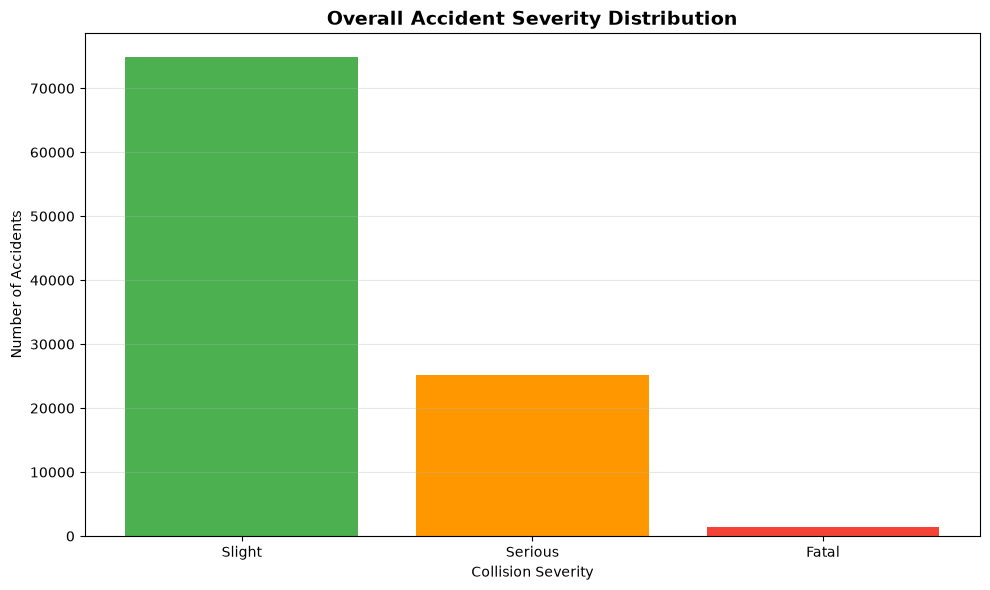

In [24]:
# Visual Summary
plt.figure(figsize=(10, 6))

top_severity = (
    df["collision_severity_label"]
    .value_counts()
    .reindex(["Slight", "Serious", "Fatal"])
)

plt.bar(
    top_severity.index,
    top_severity.values,
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Overall Accident Severity Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Collision Severity")
plt.ylabel("Number of Accidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Executive Summary

executive_summary = pd.DataFrame({
    "KPI": [
        "Total Accidents",
        "Serious/Fatal Rate",
        "Highest Accident Month",
        "Highest Accident Day",
        "Peak Accident Period",
        "Most Common Road Type",
        "Most Common Speed Limit",
        "Highest Fatal Rate Area"
    ],
    
    "Result": [
        f"{len(df):,}",
        f"{severe_accident_rate:.2f}%",
        f"{highest_accident_month['month_name']} ({highest_accident_month['accident_count']:,})",
        f"{highest_accident_day} ({day_summary.max():,})",
        f"{highest_part_of_day} ({part_of_day_summary.max():,})",
        f"{highest_road_type} ({road_summary.max():,})",
        f"{highest_speed_category} mph ({speed_summary.max():,})",
        f"{highest_fatal_rate_area} ({highest_fatal_rate:.2f}%)"
    ]
})

executive_summary

,KPI,Result
0,Total Accidents,"101,525"
1,Serious/Fatal Rate,26.24%
2,Highest Accident Month,"November (9,188)"
3,Highest Accident Day,"Friday (16,811)"
4,Peak Accident Period,"Afternoon (35,488)"
5,Most Common Road Type,"Single carriageway (74,150)"
6,Most Common Speed Limit,"30 mph (49,673)"
7,Highest Fatal Rate Area,Rural (2.71%)


## Key Findings

Based on the exploratory analysis of the 2025 road accident dataset:

### 1. Accident Severity
Most recorded collisions were classified as Slight, while Serious
and Fatal collisions represented a smaller proportion of total
collisions.

### 2. Time Pattern
Accident frequency varies across months, days of the week, and
different parts of the day. The highest-frequency periods can help
identify when road safety interventions may have greater value.

### 3. Road Characteristics
Single carriageways represented the largest share of recorded
accidents in the dataset.

### 4. Speed Limit
The 30 mph speed-limit category contained the largest number of
recorded accidents. This represents accident frequency, not accident
severity.

### 5. Environmental Conditions
Most accidents were recorded under Fine weather, Daylight, and Dry
road-surface conditions. This indicates that high accident frequency
does not necessarily mean poor weather or poor visibility.

### 6. Urban vs Rural
Urban areas recorded more accidents overall, while Rural areas showed
a higher fatal accident rate.

### 7. Vehicles and Casualties
Most accidents involved one or two vehicles. Casualty counts are
generally low, although unusual high-casualty records should be
retained and investigated rather than automatically removed.

### 8. Severity Relationships
Severity varies across road type, speed limit, weather, light,
surface, time, and area categories. These relationships should be
interpreted as associations rather than direct causes.

## Recommendations

Based on the observed patterns, the following areas could be
considered for road-safety planning:

### 1. Focus on High-Frequency Time Periods
Road-safety campaigns and traffic management resources can be
prioritized during periods with consistently high accident frequency.

### 2. Improve Safety on High-Frequency Road Types
Single-carriageway roads account for a large proportion of recorded
collisions. These locations can be prioritized for further safety
assessment.

### 3. Rural Road Safety
The higher fatal accident rate observed in rural areas suggests that
rural roads deserve specific attention, including speed management,
road design, visibility, and emergency response.

### 4. Speed Management
Speed-limit categories associated with higher serious/fatal rates can
be investigated further to understand the underlying road and traffic
conditions.

### 5. Continue Monitoring Environmental Conditions
Accidents occur frequently under normal weather and daylight
conditions, so road-safety strategies should not focus only on
extreme weather events.

### 6. Use Data for Targeted Intervention
Future analysis should combine accident frequency with severity rates
to identify locations and conditions where safety interventions may
have the greatest potential impact.

### 7. Investigate High-Casualty Events
Unusually high-casualty records should be reviewed individually to
understand the circumstances of major incidents.

## Analytical Limitations

- The analysis covers the 2025 dataset only.
- The dataset represents reported personal-injury road collisions
  recorded by the police.
- Accident frequency does not measure accident risk by itself because
  exposure data such as traffic volume are not included in this
  analysis.
- Observed relationships do not prove causation.
- Some categories contain unknown or unavailable values.
- Unusually high casualty or vehicle counts require individual
  investigation.
- The analysis does not include detailed traffic-flow, road-condition,
  driver-behaviour, or vehicle-speed exposure data.

# Conclusion

The 2025 road accident analysis identified clear patterns in accident
frequency and severity across time, road characteristics,
environmental conditions, and area type.

The analysis shows that accident frequency is concentrated in certain
road types, time periods, speed-limit categories, and normal
environmental conditions. At the same time, rural areas show a
higher fatal accident rate than urban areas.

These findings can support further investigation and targeted road
safety planning.

The project demonstrates the complete data-analysis workflow:

Raw Data
→ Data Understanding
→ Data Quality Assessment
→ Data Cleaning
→ Exploratory Data Analysis
→ Insights
→ Recommendations